# Compositional Zero-Shot Learning with CLIP

本Notebook演示如何使用CLIP模型进行组合零样本学习(CZSL)，用于雷达干扰信号的识别。

## 内容概览
1. 准备工作（安装依赖）
2. 加载CLIP模型
3. 数据加载（CZSL数据集）
4. 构建零样本分类器（包含组合）
5. 训练流程
6. 零样本评估
7. 可视化结果

## 1. 准备工作

安装必要的依赖包。如果已经安装过，可以跳过此步骤。

In [1]:
# 安装依赖
! pip install ftfy regex tqdm pyyaml h5py scikit-learn seaborn matplotlib
! pip install git+https://github.com/openai/CLIP.git

^C
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 670.4 kB/s eta 0:00:04
   --------- ------------------------------ 0.8/3.2 MB 958.5 kB/s eta 0:00:03
   ------------- -------------------------- 1.0/3.2 MB 949.8 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 1.1 MB/s eta 0:00:02
   ----------------------- ---------------- 1.8/3.2 MB 1.2 MB/s eta 0:00:02
   -------------------------- ------------- 2.1/3.2 MB 1.2 MB/s eta 0:00:01
   ------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Castle25\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


  Cloning https://github.com/openai/CLIP.git to c:\users\castle25\appdata\local\temp\pip-req-build-ing76zof
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369631 sha256=c490598d813a3ca4ca5c8a97c7cecfa71a08d4cc73ebaa92e6a7a8f0d01a7aea
  Stored in directory: C:\Users\Castle25\AppData\Local\Temp\pip-ephem-wheel-cache-d0c2e6j6\wheels\35\3e\df\3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip

   -----------------------

  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\Castle25\AppData\Local\Temp\pip-req-build-ing76zof'

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Castle25\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import yaml

# 添加项目路径
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

import clip

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

Torch version: 2.9.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2060


## 2. 加载CLIP模型

加载预训练的CLIP模型，并查看可用的模型列表。

In [4]:
# 查看可用模型
print("Available CLIP models:")
for model_name in clip.available_models():
    print(f"  - {model_name}")

Available CLIP models:
  - RN50
  - RN101
  - RN50x4
  - RN50x16
  - RN50x64
  - ViT-B/32
  - ViT-B/16
  - ViT-L/14
  - ViT-L/14@336px


In [5]:
# 设置设备和模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 加载CLIP模型
clip_model_name = "ViT-B/32"
model, preprocess = clip.load(clip_model_name, device=device)
model = model.float()  # 转换为FP32以支持微调

# 模型信息
input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size
embed_dim = model.text_projection.shape[1]

print(f"\nModel: {clip_model_name}")
print(f"Parameters: {np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print(f"Input resolution: {input_resolution}")
print(f"Context length: {context_length}")
print(f"Vocab size: {vocab_size}")
print(f"Embedding dim: {embed_dim}")

Using device: cuda

Model: ViT-B/32
Parameters: 151,277,313
Input resolution: 224
Context length: 77
Vocab size: 49408
Embedding dim: 512


## 3. 数据加载（CZSL数据集）

定义干扰类别和描述，加载STFT时频图数据。

In [6]:
# 加载配置文件
config_path = "../multi/config.yaml"  # 相对于notebooks目录

with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# 从配置中提取类别信息
jamming_classes = config.get("jamming_classes", [])
class_names = [cls["name"] for cls in jamming_classes]
class_descriptions = {cls["name"]: cls["descriptions"] for cls in jamming_classes}
num_classes = len(class_names)

# 更新模型名称（与cell-6保持一致）
clip_model_name = config.get("model", {}).get("clip_model", "ViT-B/32")

print(f"Loaded config from: {config_path}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Model from config: {clip_model_name}")

Loaded config from: ../multi/config.yaml
Number of classes: 16
Classes: ['DFTJ', 'ISRJ', 'VDJ', 'DDJ', 'AJ', 'BJ', 'SJ', 'NCJ', 'NPJ', 'SPSMJ', 'C&IJ', 'NFMJ', 'NPMJ', 'NAMJ', 'CSJ', 'PJ']
Model from config: ViT-B/32


In [7]:
# 从配置中获取Seen和Unseen组合
czsl_config = config.get("czsl", {})

# 转换组合格式（从列表的列表转为字符串列表）
seen_combinations = czsl_config.get("seen_combinations", [])
unseen_combinations = czsl_config.get("unseen_combinations", [])

print(f"Seen combinations: {len(seen_combinations)}")
for comb in seen_combinations:
    print(f"  - {comb}")

print(f"\nUnseen combinations: {len(unseen_combinations)}")
for comb in unseen_combinations[:5]:  # 只显示前5个
    print(f"  - {comb}")
if len(unseen_combinations) > 5:
    print(f"  ... and {len(unseen_combinations) - 5} more")

Seen combinations: 18
  - ['DFTJ']
  - ['ISRJ']
  - ['SPSMJ']
  - ['AJ']
  - ['BJ']
  - ['SJ']
  - ['NCJ']
  - ['NPJ']
  - ['C&IJ']
  - ['NFMJ']
  - ['NPMJ']
  - ['NAMJ']
  - ['CSJ']
  - ['PJ']
  - ['VGPO']
  - ['RGPO']
  - ['DFTJ', 'AJ']
  - ['ISRJ', 'AJ']

Unseen combinations: 3
  - ['RGPO', 'AJ']
  - ['VGPO', 'AJ']
  - ['SMSPJ', 'AJ']


In [8]:
# 从配置中获取数据配置
data_config = config.get("data", {})
train_config = config.get("train", {})

# 添加模型配置
data_config["image_size"] = config.get("data", {}).get("image_size", 224)
data_config["num_workers"] = 0  # Windows下建议设为0

# 检查数据路径是否存在
data_path = data_config.get("base_path", "")
if os.path.exists(data_path):
    print(f"Data path exists: {data_path}")
    # 列出JNR级别
    jnr_numbers = range(data_config.get("jnr_start", 0), 
                        data_config.get("jnr_end", 40) + 1, 
                        data_config.get("jnr_step", 10))
    jnr_levels = [f"+{jnr}" if jnr >= 0 else str(jnr) for jnr in jnr_numbers]
    print(f"JNR levels: {jnr_levels}")
else:
    print(f"Warning: Data path not found: {data_path}")
    print("Please update config.yaml with the correct data path.")

Data path exists: D:/VScode/Jamming_signal_simulation/NXT_Gen/output/260331
JNR levels: ['+10']


In [9]:
# 导入数据加载模块
from multi.data import CLIPSTFTDataset
from torch.utils.data import ConcatDataset

def load_czsl_data(data_config, split='train'):
    """
    加载CZSL数据
    """
    split_files = {
        'train': ('train_echo_stfts.mat', 'train_echo_label.mat'),
        'val': ('val_echo_stfts.mat', 'val_echo_label.mat'),
        'test': ('test_echo_stfts.mat', 'test_echo_label.mat')
    }
    stft_name, label_name = split_files[split]
    
    jnr_numbers = range(
        data_config.get("jnr_start", 0), 
        data_config.get("jnr_end", 40) + 1, 
        data_config.get("jnr_step", 10)
    )
    jnr_levels = [f"+{jnr}" if jnr >= 0 else str(jnr) for jnr in jnr_numbers]
    
    all_datasets = []
    base_path = data_config.get("base_path", "")
    
    for jnr in jnr_levels:
        jnr_folder = f"JNR_{jnr}"
        data_folder = os.path.join(base_path, jnr_folder)
        
        stft_file = os.path.join(data_folder, stft_name)
        label_file = os.path.join(data_folder, label_name)
        
        if os.path.exists(stft_file) and os.path.exists(label_file):
            dataset = CLIPSTFTDataset(
                stft_file=stft_file,
                label_file=label_file,
                image_size=data_config.get("image_size", 224),
                normalize_to_clip=True,
                channel_mode='real_imag_mag'
            )
            all_datasets.append(dataset)
            print(f"  Loaded {split} JNR {jnr}: {len(dataset)} samples")
    
    if not all_datasets:
        raise ValueError(f"No {split} data found!")
    
    combined = ConcatDataset(all_datasets)
    print(f"Total {split} samples: {len(combined)}")
    
    return combined

# 加载数据
print("Loading training data...")
train_dataset = load_czsl_data(data_config, 'train')

print("\nLoading validation data...")
val_dataset = load_czsl_data(data_config, 'val')

print("\nLoading test data...")
test_dataset = load_czsl_data(data_config, 'test')

Loading training data...
  Loaded train JNR +10: 230 samples
Total train samples: 230

Loading validation data...
  Loaded val JNR +10: 460 samples
Total val samples: 460

Loading test data...
  Loaded test JNR +10: 46 samples
Total test samples: 46


In [10]:
# 创建数据加载器
batch_size = 16;#train_config.get("batch_size", 16)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 16
Train batches: 15
Val batches: 29
Test batches: 3


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16, 16])
Label range: [0.0, 1.0]


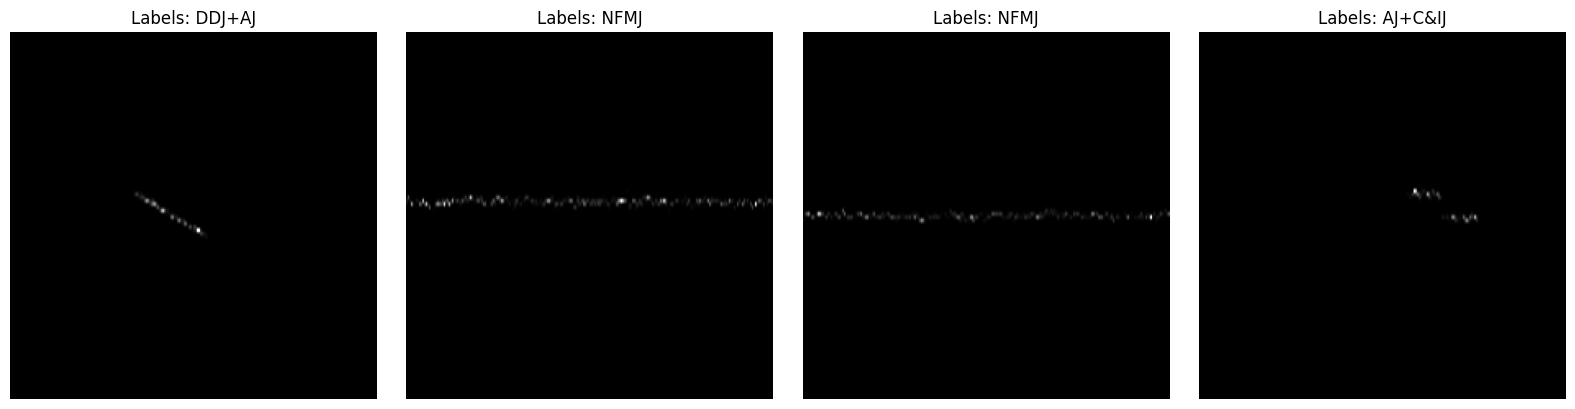

In [11]:
# 查看数据样本
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label range: [{labels.min():.1f}, {labels.max():.1f}]")

# 可视化一个样本
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    # 显示三个通道
    img = images[i].numpy()
    # 反归一化
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    img = img * std[:, None, None] + mean[:, None, None]
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (1, 2, 0))
    
    axes[i].imshow(img)
    
    # 获取标签
    label_indices = torch.where(labels[i] == 1)[0].tolist()
    label_names = [class_names[idx] for idx in label_indices]
    title = "+".join(label_names) if label_names else "None"
    axes[i].set_title(f"Labels: {title}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 构建零样本分类器

使用CLIP的文本编码器构建零样本分类器，包含单干扰和组合干扰的文本特征。

In [12]:
def build_text_features(model, class_names, class_descriptions, include_combinations=True, max_combination_size=2):
    """
    构建所有类别和组合的文本特征
    
    Returns:
        text_features: 文本特征张量 [num_features, embed_dim]
        feature_names: 特征名称列表
    """
    model.eval()
    all_features = []
    all_names = []
    
    with torch.no_grad():
        # 单类别特征
        for cls_name in class_names:
            desc = class_descriptions.get(cls_name, [cls_name])[0]
            text = clip.tokenize([desc], truncate=True).to(device)
            features = model.encode_text(text)
            features = F.normalize(features, dim=-1)
            all_features.append(features)
            all_names.append(cls_name)
        
        # 组合特征
        if include_combinations and max_combination_size >= 2:
            for i, j in combinations(range(len(class_names)), 2):
                cls1, cls2 = class_names[i], class_names[j]
                desc1 = class_descriptions.get(cls1, [cls1])[0]
                desc2 = class_descriptions.get(cls2, [cls2])[0]
                
                # 提取关键部分
                prefix = "a radar signal with "
                if desc1.startswith(prefix):
                    desc1 = desc1[len(prefix):]
                if desc2.startswith(prefix):
                    desc2 = desc2[len(prefix):]
                
                combined_desc = f"a radar signal with {desc1} and {desc2}"
                text = clip.tokenize([combined_desc], truncate=True).to(device)
                features = model.encode_text(text)
                features = F.normalize(features, dim=-1)
                all_features.append(features)
                all_names.append(f"{cls1}+{cls2}")
    
    text_features = torch.cat(all_features, dim=0)
    return text_features, all_names

# 构建文本特征
print("Building text features...")
text_features, feature_names = build_text_features(
    model, class_names, class_descriptions,
    include_combinations=True, max_combination_size=2
)

print(f"Total features: {len(feature_names)}")
print(f"  - Single classes: {num_classes}")
print(f"  - Combinations: {len(feature_names) - num_classes}")
print(f"\nFeature names: {feature_names[:10]}... (showing first 10)")

Building text features...
Total features: 136
  - Single classes: 16
  - Combinations: 120

Feature names: ['DFTJ', 'ISRJ', 'VDJ', 'DDJ', 'AJ', 'BJ', 'SJ', 'NCJ', 'NPJ', 'SPSMJ']... (showing first 10)


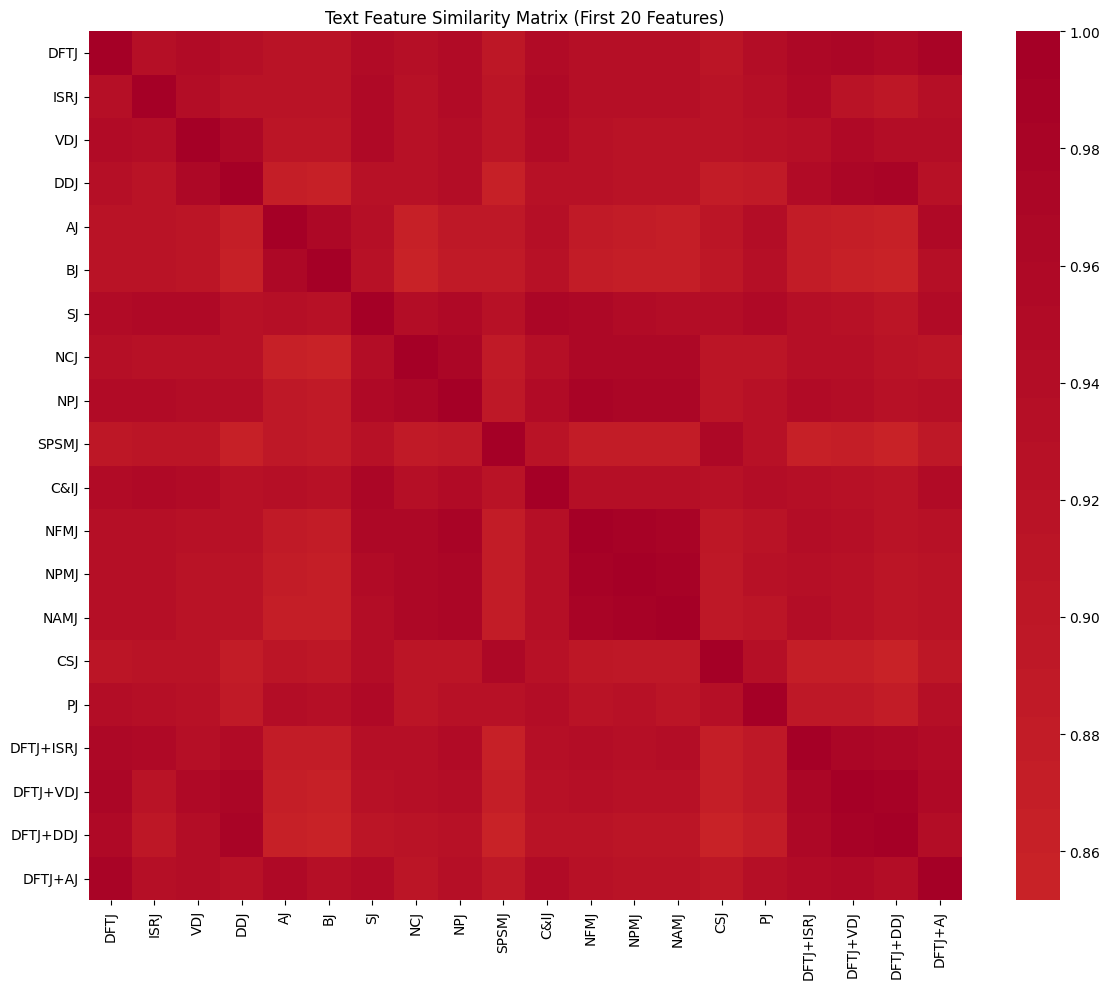

In [13]:
# 可视化文本特征的相似度矩阵
similarity_matrix = (text_features @ text_features.T).cpu().numpy()

plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix[:20, :20], 
            xticklabels=feature_names[:20], 
            yticklabels=feature_names[:20],
            cmap='RdYlBu_r', center=0)
plt.title('Text Feature Similarity Matrix (First 20 Features)')
plt.tight_layout()
plt.savefig('text_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.1 基于Metadata的文本特征（新描述模板）

使用metadata_template模块生成样本级的视觉特征描述，并计算文本特征相似度矩阵。

In [14]:
# 导入metadata模板模块
from multi.metadata_template import (
    generate_short_description, 
    JAM_TYPE_NAMES,
    get_jnr_level
)

# 打印模板信息
print("=" * 70)
print("Metadata描述模板")
print("=" * 70)
print(f"支持的干扰类型: {len(JAM_TYPE_NAMES)}种")
print(f"类型映射: {JAM_TYPE_NAMES}")
print(f"\n描述风格:")
print(f"  - 'visual': 视觉特征描述 - {{Class Name}} looks like {{description}}")
print(f"  - 'param': 参数描述 - a radar signal with {{Class Name}} at {{strength}}")
print(f"  - 'visual_param': 视觉+参数组合")

Metadata描述模板
支持的干扰类型: 16种
类型映射: {1: 'DFTJ', 2: 'ISRJ', 3: 'RGPO', 4: 'VGPO', 5: 'AJ', 6: 'BJ', 7: 'SJ', 8: 'NCJ', 9: 'NPJ', 10: 'SMSPJ', 11: 'CIJ', 12: 'NFMJ', 13: 'NPMJ', 14: 'NAMJ', 15: 'CSJ', 16: 'PJ'}

描述风格:
  - 'visual': 视觉特征描述 - {Class Name} looks like {description}
  - 'param': 参数描述 - a radar signal with {Class Name} at {strength}
  - 'visual_param': 视觉+参数组合


In [15]:
# 创建测试metadata列表 - 包含所有16种干扰类型的代表性样本
test_metadata_list = [
    # ========== 欺骗干扰 ==========
    {'jam_types': [1], 'JNR': 15, 'jam_params': {'dftj_k': 4}},  # DFTJ - few false targets
    {'jam_types': [1], 'JNR': 20, 'jam_params': {'dftj_k': 7}},  # DFTJ - many false targets
    {'jam_types': [2], 'JNR': 15, 'jam_params': {'isrj_M': 2}},  # ISRJ - simple
    {'jam_types': [2], 'JNR': 15, 'jam_params': {'isrj_M': 4}},  # ISRJ - complex
    {'jam_types': [3], 'JNR': 15, 'jam_params': {'rgpo_position_relation': 'after'}},  # RGPO
    {'jam_types': [3], 'JNR': 15, 'jam_params': {'rgpo_position_relation': 'before'}},  # RGPO
    {'jam_types': [4], 'JNR': 15, 'jam_params': {'vgpo_doppler_direction': 'up'}},  # VGPO
    {'jam_types': [4], 'JNR': 15, 'jam_params': {'vgpo_doppler_direction': 'down'}},  # VGPO
    {'jam_types': [10], 'JNR': 15, 'jam_params': {'smspj_M': 5}},  # SMSPJ
    {'jam_types': [11], 'JNR': 15, 'jam_params': {'cij_is_continuous': True}},  # CIJ
    {'jam_types': [15], 'JNR': 15, 'jam_params': {'csj_M': 5}},  # CSJ
    # ========== 压制干扰 ==========
    {'jam_types': [5], 'JNR': 15, 'jam_params': {}},  # AJ
    {'jam_types': [6], 'JNR': 15, 'jam_params': {}},  # BJ
    {'jam_types': [7], 'JNR': 15, 'jam_params': {}},  # SJ
    {'jam_types': [8], 'JNR': 15, 'jam_params': {}},  # NCJ
    {'jam_types': [9], 'JNR': 15, 'jam_params': {}},  # NPJ
    {'jam_types': [12], 'JNR': 15, 'jam_params': {}},  # NFMJ
    {'jam_types': [13], 'JNR': 15, 'jam_params': {}},  # NPMJ
    {'jam_types': [14], 'JNR': 15, 'jam_params': {}},  # NAMJ
    {'jam_types': [16], 'JNR': 15, 'jam_params': {}},  # PJ
    # ========== 组合干扰 ==========
    {'jam_types': [1, 5], 'JNR': 20, 'jam_params': {'dftj_k': 6}},  # DFTJ + AJ
    {'jam_types': [3, 5], 'JNR': 20, 'jam_params': {'rgpo_position_relation': 'after'}},  # RGPO + AJ
    {'jam_types': [2, 5], 'JNR': 20, 'jam_params': {'isrj_M': 3}},  # ISRJ + AJ
]

print(f"创建了 {len(test_metadata_list)} 个测试metadata")
print("\n示例描述:")
for i, meta in enumerate(test_metadata_list[:5]):
    desc_visual = generate_short_description(meta, style='visual')
    desc_param = generate_short_description(meta, style='param')
    print(f"\n[{i}] {meta['jam_types']}:")
    print(f"  visual: {desc_visual}")
    print(f"  param:  {desc_param}")

创建了 23 个测试metadata

示例描述:

[0] [1]:
  visual: DFTJ looks like diagonal lines in time-frequency domain with a few false targets
  param:  a radar signal with DFTJ at strong jamming power

[1] [1]:
  visual: DFTJ looks like diagonal lines in time-frequency domain with many false targets
  param:  a radar signal with DFTJ at strong jamming power

[2] [2]:
  visual: ISRJ looks like discontinuous signal slices with simple sampling pattern
  param:  a radar signal with ISRJ at strong jamming power

[3] [2]:
  visual: ISRJ looks like discontinuous signal slices with complex sampling pattern
  param:  a radar signal with ISRJ at strong jamming power

[4] [3]:
  visual: RGPO looks like false targets in range domain trailing behind real target
  param:  a radar signal with RGPO at strong jamming power


In [16]:
def build_text_features_from_metadata(model, metadata_list, style='visual', device='cuda'):
    """
    从样本级metadata构建文本特征
    
    Args:
        model: CLIP模型
        metadata_list: 样本metadata列表
        style: 描述风格 ('visual', 'param', 'visual_param')
        device: 计算设备
    
    Returns:
        text_features: [num_samples, embed_dim]
        descriptions: 每个样本的描述列表
    """
    model.eval()
    all_features = []
    all_descriptions = []
    
    with torch.no_grad():
        for metadata in tqdm(metadata_list, desc="Building text features"):
            desc = generate_short_description(metadata, style=style)
            text = clip.tokenize([desc], truncate=True).to(device)
            features = model.encode_text(text)
            features = F.normalize(features, dim=-1)
            all_features.append(features)
            all_descriptions.append(desc)
    
    text_features = torch.cat(all_features, dim=0)
    return text_features, all_descriptions


# 构建三种风格的文本特征
print("构建基于Metadata的文本特征...")
print("=" * 70)

# Visual风格
text_features_visual, desc_visual = build_text_features_from_metadata(
    model, test_metadata_list, style='visual', device=device
)
print(f"\nVisual风格文本特征: {text_features_visual.shape}")

# Param风格
text_features_param, desc_param = build_text_features_from_metadata(
    model, test_metadata_list, style='param', device=device
)
print(f"Param风格文本特征: {text_features_param.shape}")

# Visual+Param风格
text_features_vp, desc_vp = build_text_features_from_metadata(
    model, test_metadata_list, style='visual_param', device=device
)
print(f"Visual+Param风格文本特征: {text_features_vp.shape}")

构建基于Metadata的文本特征...


Building text features:   0%|          | 0/23 [00:00<?, ?it/s]


Visual风格文本特征: torch.Size([23, 512])


Building text features:   0%|          | 0/23 [00:00<?, ?it/s]

Param风格文本特征: torch.Size([23, 512])


Building text features:   0%|          | 0/23 [00:00<?, ?it/s]

Visual+Param风格文本特征: torch.Size([23, 512])


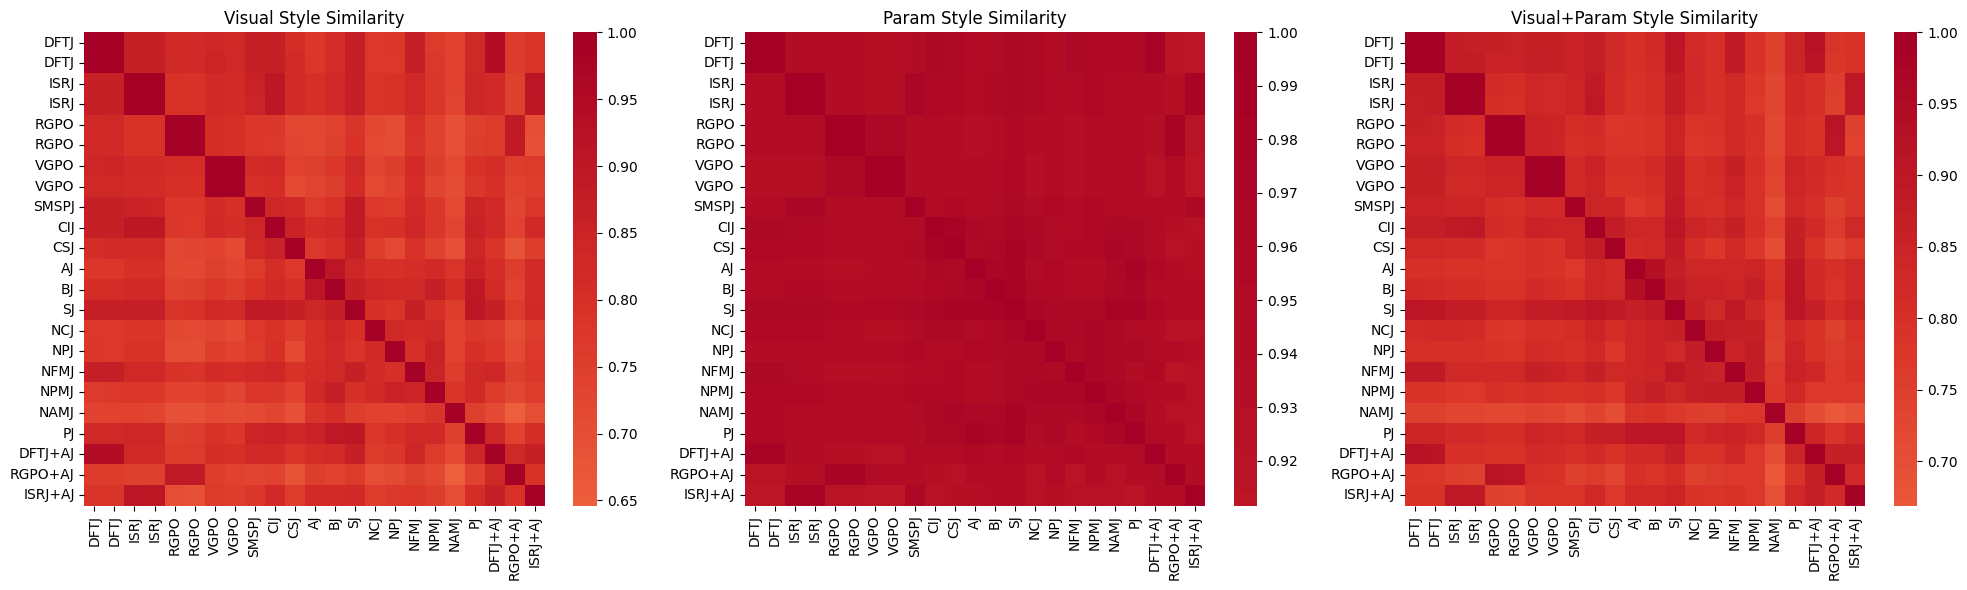


描述示例对比

[ 0] DFTJ        :
     Visual: DFTJ looks like diagonal lines in time-frequency domain with a few false targets
     Param:  a radar signal with DFTJ at strong jamming power

[ 1] DFTJ        :
     Visual: DFTJ looks like diagonal lines in time-frequency domain with many false targets
     Param:  a radar signal with DFTJ at strong jamming power

[ 2] ISRJ        :
     Visual: ISRJ looks like discontinuous signal slices with simple sampling pattern
     Param:  a radar signal with ISRJ at strong jamming power

[ 3] ISRJ        :
     Visual: ISRJ looks like discontinuous signal slices with complex sampling pattern
     Param:  a radar signal with ISRJ at strong jamming power

[ 4] RGPO        :
     Visual: RGPO looks like false targets in range domain trailing behind real target
     Param:  a radar signal with RGPO at strong jamming power

[ 5] RGPO        :
     Visual: RGPO looks like false targets in range domain leading ahead of real target
     Param:  a radar signal

In [17]:
# 可视化三种风格的文本特征相似度矩阵
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 创建简化的标签名称
def get_short_label(metadata):
    """生成简短的标签名"""
    jam_types = metadata['jam_types']
    names = [JAM_TYPE_NAMES.get(t, f'T{t}') for t in jam_types]
    return '+'.join(names)

short_labels = [get_short_label(m) for m in test_metadata_list]

# Visual风格
sim_visual = (text_features_visual @ text_features_visual.T).cpu().numpy()
sns.heatmap(sim_visual, ax=axes[0], cmap='RdYlBu_r', center=0,
            xticklabels=short_labels, yticklabels=short_labels)
axes[0].set_title('Visual Style Similarity', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

# Param风格
sim_param = (text_features_param @ text_features_param.T).cpu().numpy()
sns.heatmap(sim_param, ax=axes[1], cmap='RdYlBu_r', center=0,
            xticklabels=short_labels, yticklabels=short_labels)
axes[1].set_title('Param Style Similarity', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

# Visual+Param风格
sim_vp = (text_features_vp @ text_features_vp.T).cpu().numpy()
sns.heatmap(sim_vp, ax=axes[2], cmap='RdYlBu_r', center=0,
            xticklabels=short_labels, yticklabels=short_labels)
axes[2].set_title('Visual+Param Style Similarity', fontsize=12)
axes[2].tick_params(axis='x', rotation=90)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('metadata_text_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印描述示例
print("\n" + "=" * 70)
print("描述示例对比")
print("=" * 70)
for i in range(min(10, len(test_metadata_list))):
    print(f"\n[{i:2d}] {short_labels[i]:12s}:")
    print(f"     Visual: {desc_visual[i]}")
    print(f"     Param:  {desc_param[i]}")

对比新旧描述方式...


Building text features:   0%|          | 0/16 [00:00<?, ?it/s]

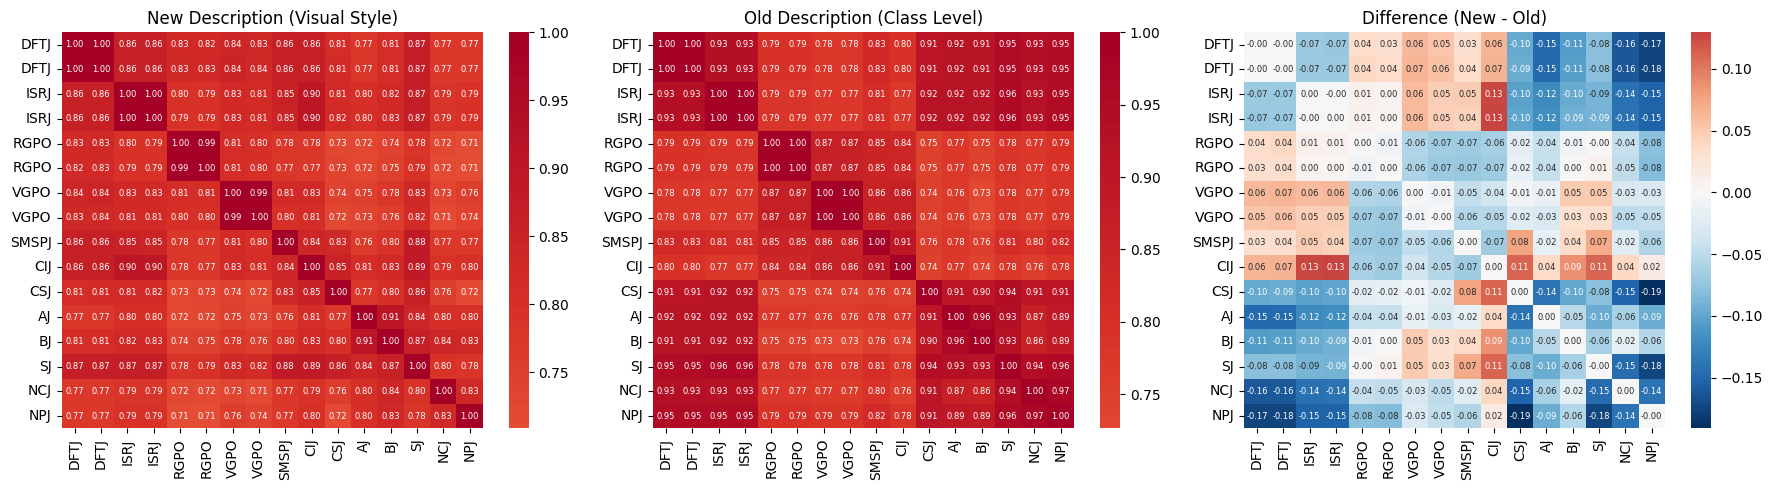


描述对比 (前10个)

[ 0] DFTJ    :
     旧描述: a radar signal with dense false target jamming...
     新描述: DFTJ looks like diagonal lines in time-frequency domain with...

[ 1] DFTJ    :
     旧描述: a radar signal with dense false target jamming...
     新描述: DFTJ looks like diagonal lines in time-frequency domain with...

[ 2] ISRJ    :
     旧描述: a radar signal with interrupted sampling repeater jamming...
     新描述: ISRJ looks like discontinuous signal slices with simple samp...

[ 3] ISRJ    :
     旧描述: a radar signal with interrupted sampling repeater jamming...
     新描述: ISRJ looks like discontinuous signal slices with complex sam...

[ 4] RGPO    :
     旧描述: RGPO...
     新描述: RGPO looks like false targets in range domain trailing behin...

[ 5] RGPO    :
     旧描述: RGPO...
     新描述: RGPO looks like false targets in range domain leading ahead ...

[ 6] VGPO    :
     旧描述: VGPO...
     新描述: VGPO looks like doppler shift pattern with increasing freque...

[ 7] VGPO    :
     旧描述: VGPO...
     新描

In [18]:
# 对比新旧描述方式的文本特征相似度

# 旧方式：使用config.yaml中的class_descriptions（类级别描述）
print("对比新旧描述方式...")
print("=" * 70)

# 提取单干扰类型的新描述（用于公平对比）
single_jam_metadata = [m for m in test_metadata_list if len(m['jam_types']) == 1][:16]

# 新描述 - Visual风格
new_features, new_desc = build_text_features_from_metadata(
    model, single_jam_metadata, style='visual', device=device
)

# 旧描述 - 类级别描述
old_features_list = []
old_desc_list = []
model.eval()
with torch.no_grad():
    for meta in single_jam_metadata:
        jam_type = meta['jam_types'][0]
        cls_name = JAM_TYPE_NAMES.get(jam_type, f'Type{jam_type}')
        old_desc = class_descriptions.get(cls_name, [cls_name])[0]
        text = clip.tokenize([old_desc], truncate=True).to(device)
        feat = model.encode_text(text)
        feat = F.normalize(feat, dim=-1)
        old_features_list.append(feat)
        old_desc_list.append(old_desc)

old_features = torch.cat(old_features_list, dim=0)

# 计算相似度矩阵
new_sim = (new_features @ new_features.T).cpu().numpy()
old_sim = (old_features @ old_features.T).cpu().numpy()

# 可视化对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 新描述相似度
labels_new = [JAM_TYPE_NAMES.get(m['jam_types'][0], f'T{m["jam_types"][0]}') for m in single_jam_metadata]
sns.heatmap(new_sim, ax=axes[0], cmap='RdYlBu_r', center=0,
            xticklabels=labels_new, yticklabels=labels_new, annot=True, fmt='.2f', annot_kws={'size': 6})
axes[0].set_title('New Description (Visual Style)', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

# 旧描述相似度
sns.heatmap(old_sim, ax=axes[1], cmap='RdYlBu_r', center=0,
            xticklabels=labels_new, yticklabels=labels_new, annot=True, fmt='.2f', annot_kws={'size': 6})
axes[1].set_title('Old Description (Class Level)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

# 差异矩阵
diff_sim = new_sim - old_sim
sns.heatmap(diff_sim, ax=axes[2], cmap='RdBu_r', center=0,
            xticklabels=labels_new, yticklabels=labels_new, annot=True, fmt='.2f', annot_kws={'size': 6})
axes[2].set_title('Difference (New - Old)', fontsize=12)
axes[2].tick_params(axis='x', rotation=90)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('old_vs_new_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印对比
print("\n" + "=" * 70)
print("描述对比 (前10个)")
print("=" * 70)
for i in range(min(10, len(single_jam_metadata))):
    print(f"\n[{i:2d}] {labels_new[i]:8s}:")
    print(f"     旧描述: {old_desc_list[i][:60]}...")
    print(f"     新描述: {new_desc[i][:60]}...")

## 5. 训练流程

使用对比学习微调CLIP模型，使其适应雷达干扰信号的识别任务。

In [19]:
# 从multi模块导入CZSL模型
from multi.model import CLIPForCZSL
from multi.loss import InfoNCELoss, CZSLContrastiveLoss

# 从配置获取模型参数
model_config = config.get("model", {})

# 创建CZSL模型
czsl_model = CLIPForCZSL(
    clip_model=model_config.get("clip_model", "ViT-B/32"),
    num_classes=num_classes,
    class_names=class_names,
    class_descriptions=class_descriptions,
    freeze_vision=model_config.get("freeze_vision", False),
    freeze_text=model_config.get("freeze_text", True),
    vision_layers_unfreeze=model_config.get("vision_layers_unfreeze", 2),
    device=str(device)
)

# 缓存文本特征
czsl_model.cache_text_features(
    max_combination_size=config.get("czsl", {}).get("zero_shot", {}).get("max_combination_size", 2),
    include_single=True
)

print(f"CZSL Model created with {sum(p.numel() for p in czsl_model.parameters()):,} parameters")
print(f"Trainable parameters: {sum(p.numel() for p in czsl_model.parameters() if p.requires_grad):,}")

Cached 136 text features:
  - Single classes: 16
  - Combinations: 120
CZSL Model created with 151,412,753 parameters
Trainable parameters: 14,312,209


In [20]:
# 从配置获取损失函数参数
loss_config = config.get("loss", {})

# 损失函数
criterion = CZSLContrastiveLoss(
    temperature=loss_config.get("temperature", 0.07),
    contrastive_weight=loss_config.get("contrastive_weight", 1.0),
    classification_weight=loss_config.get("classification_weight", 0.0),
    learnable_temperature=loss_config.get("learnable_temperature", True)
)

# 从配置获取训练参数
num_epochs = train_config.get("epochs", 10)

# 优化器
optimizer = torch.optim.AdamW(
    czsl_model.parameters(),
    lr=float(train_config.get("lr", 1e-5)),
    weight_decay=float(train_config.get("weight_decay", 0.01))
)

# 学习率调度器
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=num_epochs, 
    eta_min=config.get("train", {}).get("scheduler", {}).get("min_lr", 1e-7)
)

print(f"Training for {num_epochs} epochs")
print(f"Learning rate: {train_config.get('lr', 1e-5)}")
print(f"Weight decay: {train_config.get('weight_decay', 0.01)}")

Training for 5 epochs
Learning rate: 1e-05
Weight decay: 0.01


In [21]:
def generate_text_from_labels(labels, class_names, class_descriptions, device):
    """
    根据标签生成文本描述并编码
    
    Args:
        labels: 标签张量 [batch_size, num_classes]
        class_names: 类别名称列表
        class_descriptions: 类别描述字典
        device: 设备
    
    Returns:
        text_features: 文本特征 [batch_size, embed_dim]
    """
    batch_size = labels.shape[0]
    text_features_list = []
    
    model.eval()
    with torch.no_grad():
        for i in range(batch_size):
            # 获取正标签
            active_indices = torch.where(labels[i] == 1)[0].tolist()
            
            if len(active_indices) == 0:
                desc = "a radar signal with no jamming"
            elif len(active_indices) == 1:
                cls_name = class_names[active_indices[0]]
                desc = class_descriptions.get(cls_name, [cls_name])[0]
            else:
                # 组合干扰
                parts = []
                for idx in active_indices:
                    cls_name = class_names[idx]
                    cls_desc = class_descriptions.get(cls_name, [cls_name])[0]
                    if cls_desc.startswith("a radar signal with "):
                        cls_desc = cls_desc[len("a radar signal with "):]
                    parts.append(cls_desc)
                desc = f"a radar signal with {' and '.join(parts)}"
            
            # 编码文本
            text = clip.tokenize([desc], truncate=True).to(device)
            feat = model.encode_text(text)
            feat = F.normalize(feat, dim=-1)
            text_features_list.append(feat)
    
    text_features = torch.cat(text_features_list, dim=0)
    return text_features


def train_one_epoch_infonce(model, dataloader, optimizer, infonce_loss, device):
    """
    训练一个epoch - 使用InfoNCE对比损失（样本级对比）
    
    核心思想：
    - 为每个样本生成对应的文本描述
    - 使用InfoNCE损失让图像特征与对应文本特征对齐
    - 标准CLIP训练方式
    """
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    pbar = tqdm(dataloader, desc="Training (InfoNCE)")
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # 调整图像尺寸
        if images.shape[-1] != 224:
            images = nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
        
        batch_size = images.size(0)
        optimizer.zero_grad()
        
        # 编码图像
        image_features = model.encode_image(images)
        image_features = F.normalize(image_features, dim=-1)
        
        # 为每个样本生成文本描述并编码
        text_features = generate_text_from_labels(labels, class_names, class_descriptions, device)
        
        # 使用InfoNCE损失
        loss, logits_matrix = infonce_loss(image_features, text_features)
        
        # 反向传播
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # 统计
        total_loss += loss.item() * batch_size
        
        # 计算准确率（对角线匹配）
        with torch.no_grad():
            # 使用相似度矩阵进行预测
            preds = torch.argmax(logits_matrix, dim=1)  # [batch_size]
            targets = torch.arange(batch_size, device=device)
            correct = (preds == targets).sum().item()
            total_correct += correct
            total_samples += batch_size
        
        pbar.set_postfix(loss=loss.item())
    
    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy


def validate_infonce(model, dataloader, infonce_loss, device):
    """
    验证 - 使用InfoNCE对比损失
    """
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    pbar = tqdm(dataloader, desc="Validation (InfoNCE)")
    
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            if images.shape[-1] != 224:
                images = nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
            
            batch_size = images.shape[0]
            
            # 编码图像
            image_features = model.encode_image(images)
            image_features = F.normalize(image_features, dim=-1)
            
            # 为每个样本生成文本描述
            text_features = generate_text_from_labels(labels, class_names, class_descriptions, device)
            
            # 计算InfoNCE损失
            loss, logits_matrix = infonce_loss(image_features, text_features)
            total_loss += loss.item() * batch_size
            
            # 计算准确率
            preds = torch.argmax(logits_matrix, dim=1)
            targets = torch.arange(batch_size, device=device)
            correct = (preds == targets).sum().item()
            total_correct += correct
            total_samples += batch_size
    
    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy

print("定义了使用InfoNCE损失的训练和验证函数")
print("InfoNCE损失: 样本级对比学习，每个图像与其对应文本是正样本")

定义了使用InfoNCE损失的训练和验证函数
InfoNCE损失: 样本级对比学习，每个图像与其对应文本是正样本


In [22]:
# 创建InfoNCE损失函数
infonce_loss = InfoNCELoss(
    temperature=loss_config.get("temperature", 0.07),
    learnable_temperature=loss_config.get("learnable_temperature", True)
).to(device)

print(f"InfoNCE损失函数已创建")
print(f"温度参数: {loss_config.get('temperature', 0.07)}")
print(f"可学习温度: {loss_config.get('learnable_temperature', True)}")

# 训练循环
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_loss = float('inf')

print(f"\nStarting training for {num_epochs} epochs (InfoNCE Loss)...")
print("=" * 60)

for epoch in range(num_epochs):
    # 训练
    train_loss, train_acc = train_one_epoch_infonce(czsl_model, train_loader, optimizer, infonce_loss, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 验证
    val_loss, val_acc = validate_infonce(czsl_model, val_loader, infonce_loss, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # 更新学习率
    scheduler.step()
    
    # 打印
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(czsl_model.state_dict(), 'best_czsl_model.pt')
        print(f"  Saved best model!")
    
    print("-" * 40)

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

InfoNCE损失函数已创建
温度参数: 0.07
可学习温度: True

Starting training for 5 epochs (InfoNCE Loss)...


Training (InfoNCE):   0%|          | 0/15 [00:00<?, ?it/s]

Validation (InfoNCE):   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1/5
  Train - Loss: 2.6804, Acc: 0.1565
  Val   - Loss: 2.7417, Acc: 0.0826
  Saved best model!
----------------------------------------


Training (InfoNCE):   0%|          | 0/15 [00:00<?, ?it/s]

...

Validation (InfoNCE):   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 4/5
  Train - Loss: 1.9716, Acc: 0.4913
  Val   - Loss: 2.6553, Acc: 0.0870
  Saved best model!
----------------------------------------


Training (InfoNCE):   0%|          | 0/15 [00:00<?, ?it/s]

Validation (InfoNCE):   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 5/5
  Train - Loss: 1.8975, Acc: 0.4565
  Val   - Loss: 2.6517, Acc: 0.0870
  Saved best model!
----------------------------------------

Training completed!
Best validation loss: 2.6517


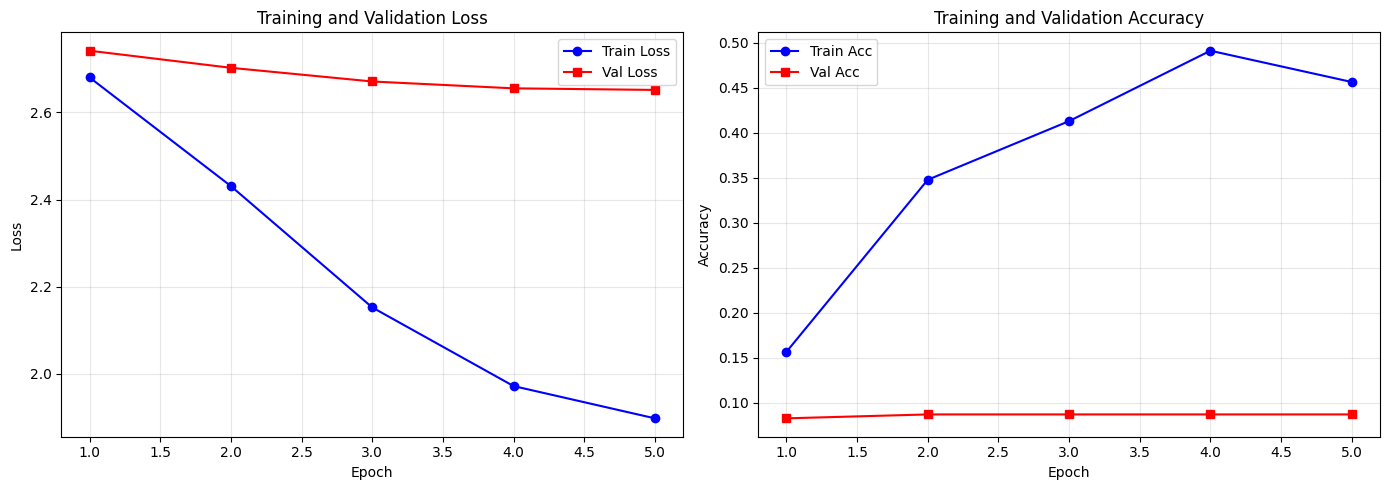

In [23]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss曲线
axes[0].plot(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss', marker='o')
axes[0].plot(range(1, num_epochs+1), val_losses, 'r-', label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy曲线
axes[1].plot(range(1, num_epochs+1), train_accs, 'b-', label='Train Acc', marker='o')
axes[1].plot(range(1, num_epochs+1), val_accs, 'r-', label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 零样本评估

评估模型在未见组合上的零样本识别能力。

In [24]:
# 加载最佳模型
czsl_model.load_state_dict(torch.load('best_czsl_model.pt', weights_only=True))
print("Loaded best model!")

# 更新文本特征缓存
czsl_model.cache_text_features(max_combination_size=2, include_single=True)

Loaded best model!
Cached 136 text features:
  - Single classes: 16
  - Combinations: 120


In [25]:
def zero_shot_evaluate(model, dataloader, class_names, device, use_combinations=True):
    """
    零样本评估
    
    Args:
        model: CZSL模型
        dataloader: 数据加载器
        class_names: 类别名称列表
        device: 设备
        use_combinations: 是否使用组合特征
    
    Returns:
        metrics: 评估指标字典
    """
    model.eval()
    
    all_labels = []
    all_preds = []
    combination_correct = 0
    total_samples = 0
    
    pbar = tqdm(dataloader, desc="Zero-shot Evaluation")
    
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            if images.shape[-1] != 224:
                images = nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
            
            batch_size = images.shape[0]
            
            # 零样本预测
            if use_combinations:
                similarities, indices, pred_names = model.zero_shot_predict(images, use_combinations=True, top_k=1)
                
                # 解析预测的组合
                preds = torch.zeros(batch_size, len(class_names), device=device)
                for i, name in enumerate(pred_names):
                    if name and len(name) > 0:
                        comb_name = name[0]
                        parts = comb_name.split('+')
                        for part in parts:
                            if part in class_names:
                                preds[i, class_names.index(part)] = 1
            else:
                probs, preds = model.zero_shot_multilabel_predict(images, threshold=0.5)
            
            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
            
            # 计算组合匹配准确率
            for i in range(batch_size):
                true_set = set(torch.where(labels[i] == 1)[0].tolist())
                pred_set = set(torch.where(preds[i] == 1)[0].tolist())
                if true_set == pred_set:
                    combination_correct += 1
                total_samples += 1
    
    # 合并结果
    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    
    # 计算指标
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    metrics = {
        "combination_accuracy": combination_correct / total_samples,
        "f1_macro": f1_score(all_labels, all_preds, average='macro', zero_division=0),
        "f1_micro": f1_score(all_labels, all_preds, average='micro', zero_division=0),
        "precision_macro": precision_score(all_labels, all_preds, average='macro', zero_division=0),
        "recall_macro": recall_score(all_labels, all_preds, average='macro', zero_division=0),
    }
    
    return metrics, all_labels, all_preds

# 评估
print("Evaluating on test set...")
metrics, test_labels, test_preds = zero_shot_evaluate(
    czsl_model, test_loader, class_names, device, use_combinations=True
)

# 打印结果
print("\n" + "=" * 60)
print("Zero-Shot Evaluation Results")
print("=" * 60)
print(f"Combination Accuracy: {metrics['combination_accuracy']:.4f}")
print(f"Macro F1 Score:       {metrics['f1_macro']:.4f}")
print(f"Micro F1 Score:       {metrics['f1_micro']:.4f}")
print(f"Macro Precision:      {metrics['precision_macro']:.4f}")
print(f"Macro Recall:         {metrics['recall_macro']:.4f}")

Evaluating on test set...


Zero-shot Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]


Zero-Shot Evaluation Results
Combination Accuracy: 0.3043
Macro F1 Score:       0.5599
Micro F1 Score:       0.5909
Macro Precision:      0.5111
Macro Recall:         0.7422


In [26]:
# 按组合类型评估（Seen vs Unseen）
def evaluate_by_combination_type(model, dataloader, class_names, seen_combinations, unseen_combinations, device):
    """
    按组合类型评估
    """
    model.eval()
    
    # 转换为set便于查找
    seen_set = set(tuple(sorted(tuple(c))) for c in seen_combinations)
    unseen_set = set(tuple(sorted(tuple(c))) for c in unseen_combinations)
    
    results = {
        "seen": {"correct": 0, "total": 0},
        "unseen": {"correct": 0, "total": 0},
        "other": {"correct": 0, "total": 0}
    }
    
    name_to_idx = {name: i for i, name in enumerate(class_names)}
    
    pbar = tqdm(dataloader, desc="Evaluating by type")
    
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            if images.shape[-1] != 224:
                images = nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
            
            # 零样本预测
            probs, preds = model.zero_shot_multilabel_predict(images, threshold=0.5)
            
            batch_size = images.shape[0]
            for i in range(batch_size):
                true_comb = tuple(sorted(torch.where(labels[i] == 1)[0].tolist()))
                pred_comb = tuple(sorted(torch.where(preds[i] == 1)[0].tolist()))
                
                is_correct = (true_comb == pred_comb)
                
                # 分类
                if true_comb in seen_set:
                    results["seen"]["total"] += 1
                    if is_correct:
                        results["seen"]["correct"] += 1
                elif true_comb in unseen_set:
                    results["unseen"]["total"] += 1
                    if is_correct:
                        results["unseen"]["correct"] += 1
                else:
                    results["other"]["total"] += 1
                    if is_correct:
                        results["other"]["correct"] += 1
    
    # 计算准确率
    final_results = {}
    for key in ["seen", "unseen", "other"]:
        total = results[key]["total"]
        correct = results[key]["correct"]
        final_results[f"{key}_accuracy"] = correct / total if total > 0 else 0
        final_results[f"{key}_samples"] = total
    
    return final_results

# 评估
print("\nEvaluating by combination type...")
type_results = evaluate_by_combination_type(
    czsl_model, test_loader, class_names, seen_combinations, unseen_combinations, device
)

print("\n" + "=" * 60)
print("Evaluation by Combination Type")
print("=" * 60)
print(f"Seen Accuracy:   {type_results['seen_accuracy']:.4f} ({type_results['seen_samples']} samples)")
print(f"Unseen Accuracy: {type_results['unseen_accuracy']:.4f} ({type_results['unseen_samples']} samples)")
print(f"Other Accuracy:  {type_results['other_accuracy']:.4f} ({type_results['other_samples']} samples)")


Evaluating by combination type...


Evaluating by type:   0%|          | 0/3 [00:00<?, ?it/s]


Evaluation by Combination Type
Seen Accuracy:   0.0000 (0 samples)
Unseen Accuracy: 0.0000 (0 samples)
Other Accuracy:  0.0000 (46 samples)


## 7. 可视化结果

展示评估结果和混淆矩阵。

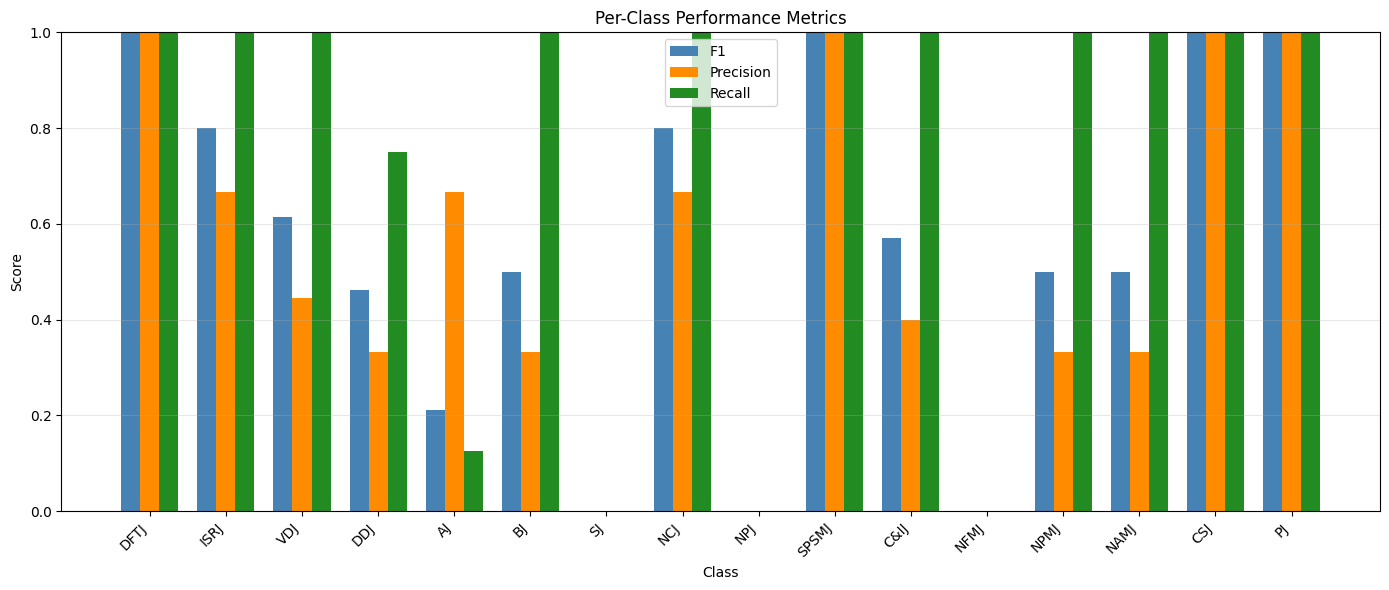

In [27]:
# 每个类别的F1分数
from sklearn.metrics import f1_score, precision_score, recall_score

per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
per_class_precision = precision_score(test_labels, test_preds, average=None, zero_division=0)
per_class_recall = recall_score(test_labels, test_preds, average=None, zero_division=0)

# 绘制条形图
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, per_class_f1, width, label='F1', color='steelblue')
bars2 = ax.bar(x, per_class_precision, width, label='Precision', color='darkorange')
bars3 = ax.bar(x + width, per_class_recall, width, label='Recall', color='forestgreen')

ax.set_xlabel('Class')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

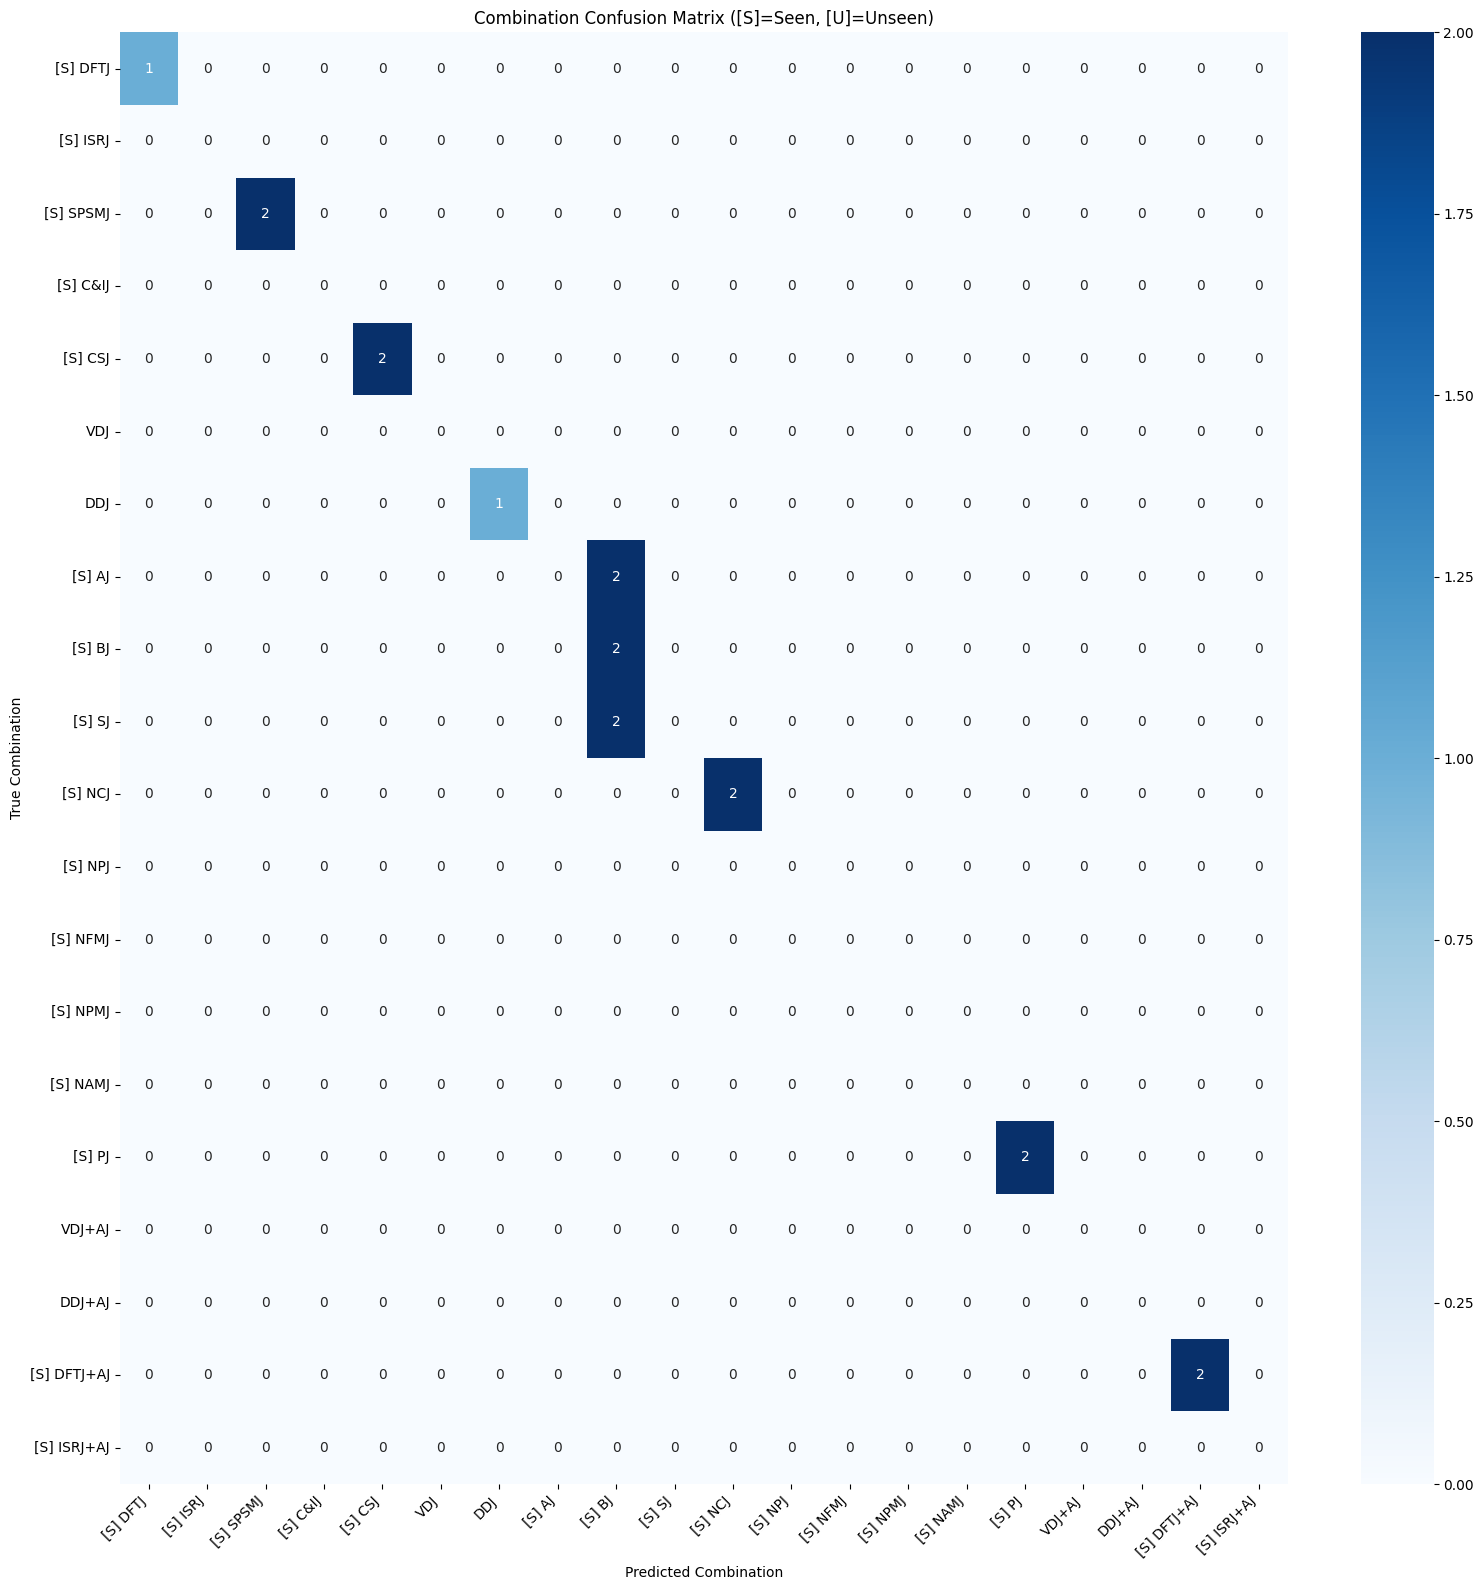


Combination Statistics:
  Seen combinations (index): [(0,), (1,), (9,), (4,), (5,), (6,), (7,), (8,), (10,), (11,), (12,), (13,), (14,), (15,), (), (), (0, 4), (1, 4)]
  Unseen combinations (index): [(4,), (4,), (4,)]
  Unique combinations in data: [(0,), (0, 2), (0, 4), (1,), (1, 4), (1, 10), (2,), (2, 3), (2, 4), (2, 10), (3,), (3, 4), (3, 10), (4,), (4, 9), (4, 10), (4, 14), (5,), (6,), (7,), (7, 10), (8,), (9,), (10,), (11,), (12,), (12, 13), (13,), (14,), (15,)]

  Sample counts per combination:
    [S] DFTJ: 2
    [S] ISRJ: 2
    [S] SPSMJ: 2
    [S] C&IJ: 2
    [S] CSJ: 2
     VDJ: 2
     DDJ: 2
    [S] AJ: 2
    [S] BJ: 2
    [S] SJ: 2


In [29]:
# 绘制组合混淆矩阵
def plot_combination_confusion(labels, preds, class_names, seen_combinations=None, unseen_combinations=None):
    """
    绘制组合混淆矩阵
    """
    # 将类别名称组合转换为索引组合
    name_to_idx = {name: i for i, name in enumerate(class_names)}
    
    def convert_to_index_comb(combinations):
        """将类别名称组合转换为索引组合"""
        if not combinations:
            return []
        result = []
        for comb in combinations:
            indices = tuple(sorted(name_to_idx[name] for name in comb if name in name_to_idx))
            result.append(indices)
        return result
    
    seen_index_combs = convert_to_index_comb(seen_combinations)
    unseen_index_combs = convert_to_index_comb(unseen_combinations)
    
    # 从数据中提取所有出现的组合
    true_combinations = []
    pred_combinations = []
    
    for i in range(len(labels)):
        true_comb = tuple(sorted(np.where(labels[i] == 1)[0].tolist()))
        pred_comb = tuple(sorted(np.where(preds[i] == 1)[0].tolist()))
        true_combinations.append(true_comb)
        pred_combinations.append(pred_comb)
    
    # 获取所有唯一的组合
    unique_combs = sorted(set(true_combinations + pred_combinations))
    
    # 只显示出现频率最高的组合
    comb_counts = {}
    for comb in true_combinations:
        comb_counts[comb] = comb_counts.get(comb, 0) + 1
    
    # 取前20个最常见的组合
    top_combs = sorted(comb_counts.keys(), key=lambda x: comb_counts[x], reverse=True)[:20]
    comb_to_idx = {comb: i for i, comb in enumerate(top_combs)}
    
    # 构建混淆矩阵
    n_combs = len(top_combs)
    confusion = np.zeros((n_combs, n_combs), dtype=int)
    
    for i in range(len(labels)):
        true_comb = tuple(sorted(np.where(labels[i] == 1)[0].tolist()))
        pred_comb = tuple(sorted(np.where(preds[i] == 1)[0].tolist()))
        
        if true_comb in comb_to_idx and pred_comb in comb_to_idx:
            confusion[comb_to_idx[true_comb], comb_to_idx[pred_comb]] += 1
    
    # 转换为名称并标记 Seen/Unseen
    seen_set = set(seen_index_combs)
    unseen_set = set(unseen_index_combs)
    
    comb_names = []
    for comb in top_combs:
        if len(comb) == 0:
            name = "None"
        else:
            name = "+".join([class_names[i] for i in comb])
        
        # 添加标记
        if comb in seen_set:
            name = f"[S] {name}"
        elif comb in unseen_set:
            name = f"[U] {name}"
        
        comb_names.append(name)
    
    # 绘图
    fig_size = max(10, n_combs * 0.8)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
                xticklabels=comb_names, yticklabels=comb_names, ax=ax)
    ax.set_xlabel('Predicted Combination')
    ax.set_ylabel('True Combination')
    ax.set_title('Combination Confusion Matrix ([S]=Seen, [U]=Unseen)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('combination_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 打印组合统计
    print("\nCombination Statistics:")
    print(f"  Seen combinations (index): {seen_index_combs}")
    print(f"  Unseen combinations (index): {unseen_index_combs}")
    print(f"  Unique combinations in data: {unique_combs}")
    print(f"\n  Sample counts per combination:")
    for comb, count in sorted(comb_counts.items(), key=lambda x: -x[1])[:10]:
        name = "+".join([class_names[i] for i in comb]) if comb else "None"
        tag = "[S]" if comb in seen_set else ("[U]" if comb in unseen_set else "")
        print(f"    {tag} {name}: {count}")

# 绘制混淆矩阵
plot_combination_confusion(test_labels, test_preds, class_names, seen_combinations, unseen_combinations)

In [ ]:
# 可视化特征分布（使用t-SNE）
from sklearn.manifold import TSNE

def visualize_features(model, dataloader, class_names, device, num_samples=500):
    """
    使用t-SNE可视化特征分布
    """
    model.eval()
    
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            
            if images.shape[-1] != 224:
                images = nn.functional.interpolate(images, size=(224, 224), mode='bilinear', align_corners=False)
            
            features = model.encode_image(images)
            features = F.normalize(features, dim=-1)
            
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
            
            if len(all_features) * images.shape[0] >= num_samples:
                break
    
    features = np.concatenate(all_features, axis=0)[:num_samples]
    labels = np.concatenate(all_labels, axis=0)[:num_samples]
    
    # 获取主要类别（每个样本的第一个正标签）
    primary_labels = []
    for label in labels:
        active = np.where(label == 1)[0]
        if len(active) > 0:
            primary_labels.append(active[0])
        else:
            primary_labels.append(-1)
    primary_labels = np.array(primary_labels)
    
    # t-SNE降维
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)
    
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 为每个类别绘制散点
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))
    
    for i, cls_name in enumerate(class_names):
        mask = primary_labels == i
        if mask.sum() > 0:
            ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                      c=[colors[i]], label=cls_name, alpha=0.6, s=30)
    
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title('Feature Distribution (t-SNE)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('feature_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

# 可视化
visualize_features(czsl_model, test_loader, class_names, device)

**保存所有STFT图像**

python -m multi.evaluate_czsl --checkpoint checkpoints/czsl_best_model.pt --config multi/config.yaml --mode zero_shot --save_stft

**只保存前100张图像**

python -m multi.evaluate_czsl --checkpoint checkpoints/czsl_best_model.pt --config multi/config.yaml --mode zero_shot --save_stft --max_stft_samples 100

**同时生成可视化和STFT图像**

python -m multi.evaluate_czsl --checkpoint checkpoints/czsl_best_model.pt --config multi/config.yaml --mode zero_shot --visualize --save_stft


In [ ]:
!python -m multi.evaluate_czsl --checkpoint checkpoints/czsl_best_model.pt --config multi/config.yaml --mode zero_shot --visualize


In [ ]:
# 总结
print("\n" + "=" * 60)
print("CZSL Experiment Summary")
print("=" * 60)
print(f"\nModel: {clip_model_name}")
print(f"Number of classes: {num_classes}")
print(f"Training epochs: {num_epochs}")
print(f"\nData Statistics:")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")
print(f"\nCZSL Settings:")
print(f"  - Seen combinations: {len(seen_combinations)}")
print(f"  - Unseen combinations: {len(unseen_combinations)}")
print(f"\nFinal Results:")
print(f"  - Combination Accuracy: {metrics['combination_accuracy']:.4f}")
print(f"  - Macro F1 Score: {metrics['f1_macro']:.4f}")
print(f"  - Seen Accuracy: {type_results['seen_accuracy']:.4f}")
print(f"  - Unseen Accuracy: {type_results['unseen_accuracy']:.4f}")
print("\n" + "=" * 60)